In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 6.8 MB/s eta 0:00:00


In [3]:
!pip install PyDrive

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 987.4/987.4 kB 19.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for PyDrive: filename=PyDrive-1.3.1-py3-none-any.whl size=27433 sha256=55436e2987cb53c451e81871667c1e6989150029a9693d2caa7ae40ff5a59a95
  Stored in directory: /root/.cache/pip/wheels/6c/10/da/a5b513f5b3916fc391c20ee7b4633e5cf3396d570cdd74970f
Successfully built PyDrive


In [4]:
# General-purpose imports
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from urllib.parse import quote
import webbrowser
import random
from collections import defaultdict
from base64 import b64decode

# Scikit-learn imports
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# Imbalanced-learn imports
from imblearn.over_sampling import SMOTE

# TensorFlow and Keras imports
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization,
    Input, GlobalAveragePooling2D, SeparableConv2D, Multiply
)
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import EfficientNetB0, MobileNetV2

# For AdamW optimizer (if available)
try:
    from tensorflow.keras.optimizers import AdamW
except ImportError:
    AdamW = Adam

# IPython displays
from IPython.display import display

# Kerastuner imports
from kerastuner.tuners import RandomSearch

# Google Colab imports
from IPython.display import display, Javascript
from google.colab.output import eval_js
from google.colab import files
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

/tmp/ipython-input-4035724408.py:46: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  from kerastuner.tuners import RandomSearch


In [5]:
# Kaggle imports
import kagglehub

import zipfile
import os

# Path to your ZIP file in Google Drive
zip_path = "/content/drive/MyDrive/fer2013/fer2013.zip"

# Destination folder where contents will be extracted
extract_path = "/content/fer2013"

# Extract the ZIP
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Check extracted folders/files
print(os.listdir(extract_path))

['test', 'train']


Found 22619 images belonging to 6 classes.
Found 5654 images belonging to 6 classes.
Found 7067 images belonging to 6 classes.
Data generators created successfully!
Training samples: 22619
Validation samples: 5654
Test samples: 7067
Building DenseNet121 with Attention...
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Building Custom Attention Model...

Training DenseNet121...
Epoch 1/50
353/354 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.2227 - loss: 2.3914
Epoch 1: val_accuracy improved from -inf to 0.32685, saving model to best_densenet.h5


354/354 ━━━━━━━━━━━━━━━━━━━━ 132s 218ms/step - accuracy: 0.2229 - loss: 2.3905 - val_accuracy: 0.3268 - val_loss: 1.6686 - learning_rate: 1.0000e-04
Epoch 2/50
353/354 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.2936 - loss: 1.9986
Epoch 2: val_accuracy improved from 0.32685 to 0.36081, saving model to best_densenet.h5


354/354 ━━━━━━━━━━━━━━━━━━━━ 26s 74ms/step - accuracy: 0.2936 - loss: 1.9985 - val_accuracy: 0.3608 - val_loss: 1.6071 - learning_rate: 1.0000e-04
Epoch 3/50
354/354 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.3113 - loss: 1.8903
Epoch 3: val_accuracy improved from 0.36081 to 0.36841, saving model to best_densenet.h5


354/354 ━━━━━━━━━━━━━━━━━━━━ 27s 76ms/step - accuracy: 0.3113 - loss: 1.8903 - val_accuracy: 0.3684 - val_loss: 1.5893 - learning_rate: 1.0000e-04
Epoch 4/50
353/354 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.3163 - loss: 1.8304
Epoch 4: val_accuracy improved from 0.36841 to 0.37283, saving model to best_densenet.h5


354/354 ━━━━━━━━━━━━━━━━━━━━ 26s 74ms/step - accuracy: 0.3163 - loss: 1.8303 - val_accuracy: 0.3728 - val_loss: 1.5780 - learning_rate: 1.0000e-04
Epoch 5/50
354/354 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.3316 - loss: 1.7851
Epoch 5: val_accuracy improved from 0.37283 to 0.38716, saving model to best_densenet.h5


...

354/354 ━━━━━━━━━━━━━━━━━━━━ 23s 66ms/step - accuracy: 0.5947 - loss: 1.0448 - val_accuracy: 0.5946 - val_loss: 1.0492 - learning_rate: 1.0000e-04
Epoch 30/50
354/354 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.6057 - loss: 1.0361
Epoch 30: val_accuracy did not improve from 0.59462
354/354 ━━━━━━━━━━━━━━━━━━━━ 24s 68ms/step - accuracy: 0.6057 - loss: 1.0361 - val_accuracy: 0.5902 - val_loss: 1.0738 - learning_rate: 1.0000e-04
Epoch 31/50
354/354 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5938 - loss: 1.0396
Epoch 31: val_accuracy did not improve from 0.59462
354/354 ━━━━━━━━━━━━━━━━━━━━ 25s 69ms/step - accuracy: 0.5938 - loss: 1.0396 - val_accuracy: 0.5921 - val_loss: 1.0834 - learning_rate: 1.0000e-04
Epoch 32/50
354/354 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.6128 - loss: 1.0302
Epoch 32: val_accuracy did not improve from 0.59462
354/354 ━━━━━━━━━━━━━━━━━━━━ 24s 69ms/step - accuracy: 0.6128 - loss: 1.0302 - val_accuracy: 0.5745 - val_loss: 1.1104 - learning_rate: 1.0

354/354 ━━━━━━━━━━━━━━━━━━━━ 25s 69ms/step - accuracy: 0.6108 - loss: 1.0196 - val_accuracy: 0.6109 - val_loss: 1.0369 - learning_rate: 1.0000e-04
Epoch 35/50
354/354 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.6168 - loss: 0.9936
Epoch 35: val_accuracy did not improve from 0.61089
354/354 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.6168 - loss: 0.9936 - val_accuracy: 0.6054 - val_loss: 1.0403 - learning_rate: 1.0000e-04
Epoch 36/50
354/354 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.6126 - loss: 1.0099
Epoch 36: val_accuracy did not improve from 0.61089
354/354 ━━━━━━━━━━━━━━━━━━━━ 24s 68ms/step - accuracy: 0.6126 - loss: 1.0099 - val_accuracy: 0.5953 - val_loss: 1.0825 - learning_rate: 1.0000e-04
Epoch 37/50
354/354 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6174 - loss: 1.0035
Epoch 37: val_accuracy did not improve from 0.61089
354/354 ━━━━━━━━━━━━━━━━━━━━ 25s 70ms/step - accuracy: 0.6174 - loss: 1.0035 - val_accuracy: 0.6051 - val_loss: 1.0550 - learning_rate: 1.0

354/354 ━━━━━━━━━━━━━━━━━━━━ 25s 69ms/step - accuracy: 0.6263 - loss: 0.9646 - val_accuracy: 0.6183 - val_loss: 1.0138 - learning_rate: 1.0000e-04
Epoch 42/50
354/354 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.6301 - loss: 0.9547
Epoch 42: val_accuracy did not improve from 0.61832
354/354 ━━━━━━━━━━━━━━━━━━━━ 24s 69ms/step - accuracy: 0.6301 - loss: 0.9548 - val_accuracy: 0.6139 - val_loss: 1.0405 - learning_rate: 1.0000e-04
Epoch 43/50
354/354 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.6342 - loss: 0.9590
Epoch 43: val_accuracy improved from 0.61832 to 0.62292, saving model to best_custom.h5


354/354 ━━━━━━━━━━━━━━━━━━━━ 25s 70ms/step - accuracy: 0.6341 - loss: 0.9590 - val_accuracy: 0.6229 - val_loss: 1.0115 - learning_rate: 1.0000e-04
Epoch 44/50
354/354 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6390 - loss: 0.9537
Epoch 44: val_accuracy did not improve from 0.62292
354/354 ━━━━━━━━━━━━━━━━━━━━ 25s 70ms/step - accuracy: 0.6390 - loss: 0.9537 - val_accuracy: 0.6153 - val_loss: 1.0217 - learning_rate: 1.0000e-04
Epoch 45/50
354/354 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6412 - loss: 0.9452
Epoch 45: val_accuracy did not improve from 0.62292
354/354 ━━━━━━━━━━━━━━━━━━━━ 24s 68ms/step - accuracy: 0.6412 - loss: 0.9452 - val_accuracy: 0.6196 - val_loss: 1.0107 - learning_rate: 1.0000e-04
Epoch 46/50
354/354 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.6459 - loss: 0.9362
Epoch 46: val_accuracy did not improve from 0.62292
354/354 ━━━━━━━━━━━━━━━━━━━━ 24s 68ms/step - accuracy: 0.6459 - loss: 0.9362 - val_accuracy: 0.6208 - val_loss: 1.0110 - learning_rate: 1.0

354/354 ━━━━━━━━━━━━━━━━━━━━ 25s 70ms/step - accuracy: 0.6453 - loss: 0.9265 - val_accuracy: 0.6296 - val_loss: 0.9930 - learning_rate: 1.0000e-04
Epoch 49/50
354/354 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6524 - loss: 0.9141
Epoch 49: val_accuracy did not improve from 0.62964
354/354 ━━━━━━━━━━━━━━━━━━━━ 25s 69ms/step - accuracy: 0.6524 - loss: 0.9141 - val_accuracy: 0.6201 - val_loss: 1.0111 - learning_rate: 1.0000e-04
Epoch 50/50
354/354 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6518 - loss: 0.9215
Epoch 50: val_accuracy did not improve from 0.62964
354/354 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.6518 - loss: 0.9215 - val_accuracy: 0.6031 - val_loss: 1.0319 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 48.

Evaluating Individual Models...
111/111 ━━━━━━━━━━━━━━━━━━━━ 27s 137ms/step
Classification Report for DenseNet121
              precision    recall  f1-score   support

       angry       0.40      0.32      0.35      

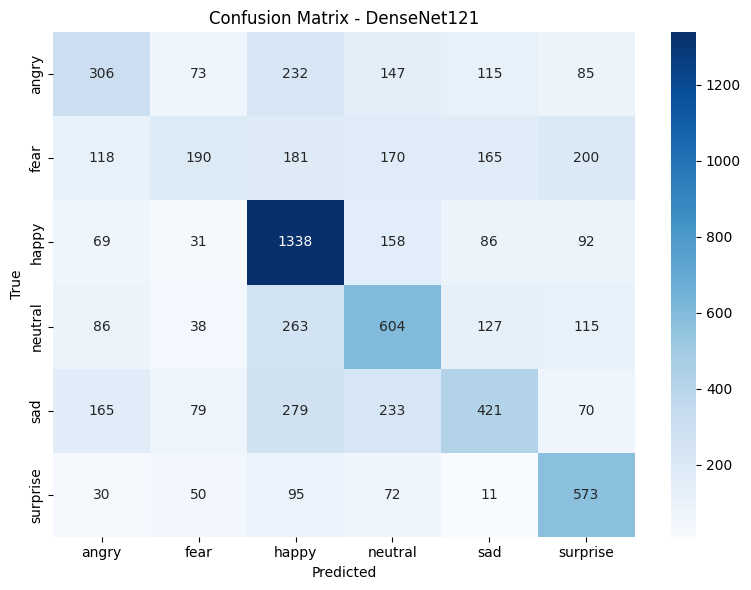

111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step
Classification Report for Custom CNN
              precision    recall  f1-score   support

       angry       0.61      0.53      0.57       958
        fear       0.52      0.38      0.43      1024
       happy       0.82      0.87      0.84      1774
     neutral       0.57      0.62      0.59      1233
         sad       0.53      0.53      0.53      1247
    surprise       0.69      0.82      0.75       831

    accuracy                           0.64      7067
   macro avg       0.62      0.62      0.62      7067
weighted avg       0.64      0.64      0.64      7067



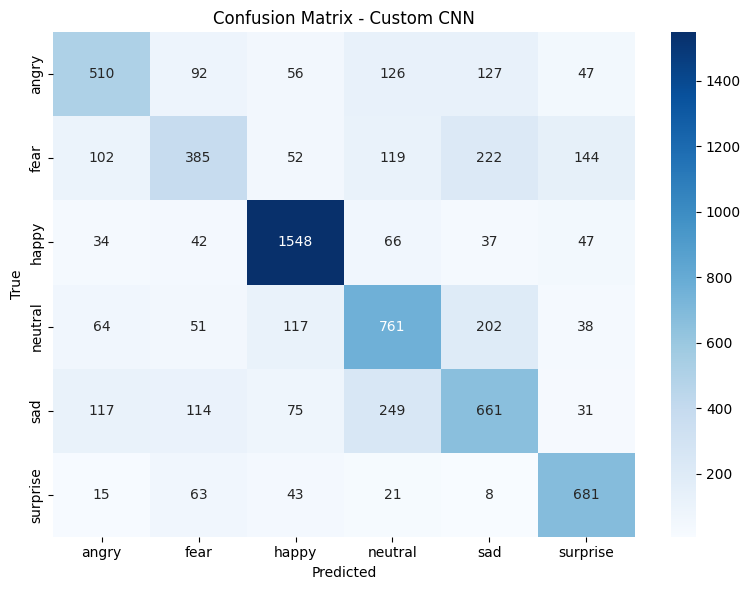


Building Ensemble Model...
111/111 ━━━━━━━━━━━━━━━━━━━━ 29s 144ms/step
Classification Report for Ensemble Model
              precision    recall  f1-score   support

       angry       0.59      0.51      0.55       958
        fear       0.56      0.32      0.40      1024
       happy       0.74      0.90      0.81      1774
     neutral       0.57      0.61      0.59      1233
         sad       0.54      0.49      0.51      1247
    surprise       0.65      0.83      0.73       831

    accuracy                           0.63      7067
   macro avg       0.61      0.61      0.60      7067
weighted avg       0.62      0.63      0.62      7067



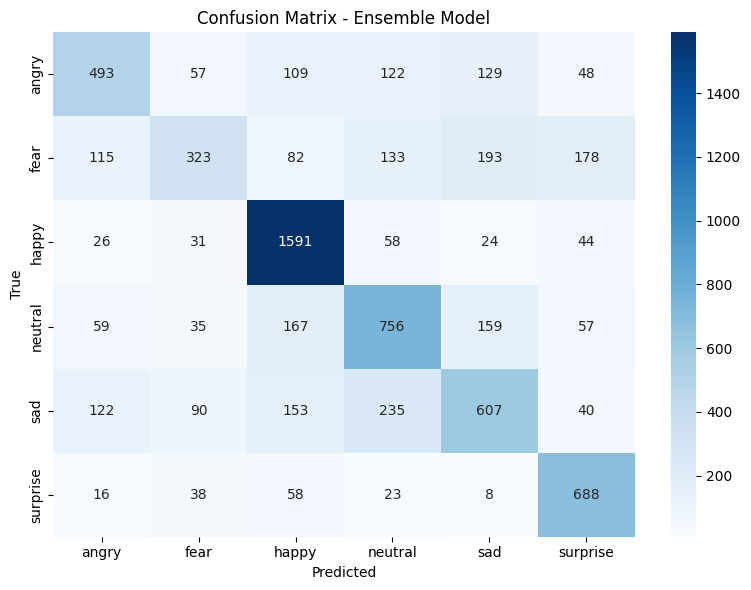


FINAL RESULTS
DenseNet121 Accuracy: 0.4856
Custom CNN Accuracy: 0.6433
Ensemble Accuracy: 0.6308

Saving ensemble model for Streamlit...
✅ Ensemble model saved as 'emotion_model.h5'
✅ Class labels saved as 'class_labels.json'

🎯 Training completed! Use 'emotion_model.h5' in your Streamlit app.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.layers import Multiply, Activation, Reshape, Lambda, Input, Average
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')

# ---------------------------- Configurations ---------------------------- #
IMAGE_SIZE = 48
BATCH_SIZE = 64
EPOCHS = 50  # Reduced epochs for faster training

TRAIN_PATH = "/content/fer2013/train"
TEST_PATH = "/content/fer2013/test"
SELECTED_CLASSES = ['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise']

# ---------------------------- Attention Mechanisms ---------------------------- #
def channel_attention(input_tensor, reduction_ratio=8):
    """Channel Attention Module (CAM)"""
    channels = input_tensor.shape[-1]
    gap = GlobalAveragePooling2D()(input_tensor)
    gap = Dense(channels // reduction_ratio, activation='relu')(gap)
    gap = Dense(channels, activation='sigmoid')(gap)

    gmp = tf.keras.layers.GlobalMaxPooling2D()(input_tensor)
    gmp = Dense(channels // reduction_ratio, activation='relu')(gmp)
    gmp = Dense(channels, activation='sigmoid')(gmp)

    attention = tf.keras.layers.Add()([gap, gmp])
    attention = Activation('sigmoid')(attention)
    attention = Reshape((1, 1, channels))(attention)
    return Multiply()([input_tensor, attention])

def spatial_attention(input_tensor):
    """Spatial Attention Module (SAM)"""
    avg_pool = Lambda(lambda x: tf.reduce_mean(x, axis=3, keepdims=True))(input_tensor)
    max_pool = Lambda(lambda x: tf.reduce_max(x, axis=3, keepdims=True))(input_tensor)
    concat = tf.keras.layers.Concatenate(axis=3)([avg_pool, max_pool])
    attention = Conv2D(1, (7, 7), padding='same', activation='sigmoid')(concat)
    return Multiply()([input_tensor, attention])

def cbam_attention(input_tensor, reduction_ratio=8):
    """Convolutional Block Attention Module (CBAM)"""
    x = channel_attention(input_tensor, reduction_ratio)
    x = spatial_attention(x)
    return x

# ---------------------------- Data Generators ---------------------------- #
def create_grayscale_generators(train_path, test_path, img_size, batch_size, selected_classes):
    """Create grayscale data generators."""
    train_preprocessor = ImageDataGenerator(
        rescale=1./255,
        rotation_range=15,
        zoom_range=0.2,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,
        validation_split=0.2
    )

    test_preprocessor = ImageDataGenerator(rescale=1./255)

    train_generator = train_preprocessor.flow_from_directory(
        train_path,
        target_size=(img_size, img_size),
        color_mode='grayscale',
        batch_size=batch_size,
        class_mode="categorical",
        subset="training",
        classes=selected_classes,
        shuffle=True
    )

    validation_generator = train_preprocessor.flow_from_directory(
        train_path,
        target_size=(img_size, img_size),
        color_mode='grayscale',
        batch_size=batch_size,
        class_mode="categorical",
        subset="validation",
        classes=selected_classes,
        shuffle=False
    )

    test_generator = test_preprocessor.flow_from_directory(
        test_path,
        target_size=(img_size, img_size),
        color_mode='grayscale',
        batch_size=batch_size,
        class_mode="categorical",
        shuffle=False,
        classes=selected_classes
    )

    return train_generator, validation_generator, test_generator

# ---------------------------- Model Building ---------------------------- #
def build_densenet121_with_attention(input_shape, num_classes):
    """Build DenseNet121 model with CBAM attention."""
    base_model = DenseNet121(
        weights='imagenet',
        include_top=False,
        input_shape=(input_shape[0], input_shape[1], 3)
    )

    inputs = Input(shape=input_shape)
    x = Lambda(lambda x: tf.repeat(x, 3, axis=-1))(inputs)
    x = base_model(x, training=False)
    x = cbam_attention(x, reduction_ratio=16)
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)

    # Fine-tuning
    base_model.trainable = True
    for layer in base_model.layers[:-60]:  # Reduced unfrozen layers
        layer.trainable = False

    return model

def build_custom_attention_model(input_shape, num_classes):
    """Build custom CNN model with attention mechanisms."""
    inputs = Input(shape=input_shape)

    # Block 1
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.25)(x)

    # Block 2 with attention
    x = channel_attention(x, reduction_ratio=8)
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.25)(x)

    # Block 3 with attention
    x = spatial_attention(x)
    x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.25)(x)

    # Classifier
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs)

def build_ensemble_model(densenet_model, custom_model, input_shape, num_classes):
    """Build ensemble model that averages predictions from both models."""
    input_layer = Input(shape=input_shape)

    # Get predictions from both models
    densenet_pred = densenet_model(input_layer)
    custom_pred = custom_model(input_layer)

    # Average the predictions
    averaged = Average()([densenet_pred, custom_pred])

    # Create ensemble model
    ensemble_model = Model(inputs=input_layer, outputs=averaged)

    return ensemble_model

# ---------------------------- Callbacks ---------------------------- #
def get_callbacks(model_name):
    """Get callbacks for training."""
    checkpoint = ModelCheckpoint(
        f"best_{model_name}.h5",
        monitor="val_accuracy",
        save_best_only=True,
        mode='max',
        verbose=1
    )

    early_stopping = EarlyStopping(
        monitor="val_accuracy",
        patience=15,
        restore_best_weights=True,
        mode='max',
        verbose=1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )

    return [checkpoint, early_stopping, reduce_lr]

# ---------------------------- Evaluation ---------------------------- #
def evaluate_model(model, generator, selected_classes, title):
    """Evaluate model and plot confusion matrix."""
    predictions = model.predict(generator)
    pred_classes = np.argmax(predictions, axis=1)
    true_classes = generator.classes

    print(f"Classification Report for {title}")
    print(classification_report(true_classes, pred_classes, target_names=selected_classes))

    # Confusion Matrix
    cm = confusion_matrix(true_classes, pred_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=selected_classes, yticklabels=selected_classes)
    plt.title(f"Confusion Matrix - {title}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    return np.mean(pred_classes == true_classes)

# ---------------------------- Main Pipeline ---------------------------- #
if __name__ == "__main__":
    # Create data generators
    train_gen, val_gen, test_gen = create_grayscale_generators(
        TRAIN_PATH, TEST_PATH, IMAGE_SIZE, BATCH_SIZE, SELECTED_CLASSES
    )

    print("Data generators created successfully!")
    print(f"Training samples: {train_gen.samples}")
    print(f"Validation samples: {val_gen.samples}")
    print(f"Test samples: {test_gen.samples}")

    # Build models
    print("Building DenseNet121 with Attention...")
    densenet_model = build_densenet121_with_attention((IMAGE_SIZE, IMAGE_SIZE, 1), len(SELECTED_CLASSES))
    densenet_model.compile(optimizer=Adam(0.0001), loss="categorical_crossentropy", metrics=["accuracy"])

    print("Building Custom Attention Model...")
    custom_model = build_custom_attention_model((IMAGE_SIZE, IMAGE_SIZE, 1), len(SELECTED_CLASSES))
    custom_model.compile(optimizer=Adam(0.0001), loss="categorical_crossentropy", metrics=["accuracy"])

    # Train models
    print("\nTraining DenseNet121...")
    history_densenet = densenet_model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=get_callbacks("densenet"),
        verbose=1
    )

    print("\nTraining Custom Model...")
    history_custom = custom_model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=get_callbacks("custom"),
        verbose=1
    )

    # Evaluate individual models
    print("\nEvaluating Individual Models...")
    densenet_acc = evaluate_model(densenet_model, test_gen, SELECTED_CLASSES, "DenseNet121")
    custom_acc = evaluate_model(custom_model, test_gen, SELECTED_CLASSES, "Custom CNN")

    # Build and save ensemble model
    print("\nBuilding Ensemble Model...")
    ensemble_model = build_ensemble_model(densenet_model, custom_model, (IMAGE_SIZE, IMAGE_SIZE, 1), len(SELECTED_CLASSES))
    ensemble_model.compile(optimizer=Adam(0.0001), loss="categorical_crossentropy", metrics=["accuracy"])

    # Evaluate ensemble
    ensemble_acc = evaluate_model(ensemble_model, test_gen, SELECTED_CLASSES, "Ensemble Model")

    # Print results
    print("\n" + "="*50)
    print("FINAL RESULTS")
    print("="*50)
    print(f"DenseNet121 Accuracy: {densenet_acc:.4f}")
    print(f"Custom CNN Accuracy: {custom_acc:.4f}")
    print(f"Ensemble Accuracy: {ensemble_acc:.4f}")

    # Save the ensemble model for Streamlit
    print("\nSaving ensemble model for Streamlit...")
    ensemble_model.save('emotion_model.h5')
    print("✅ Ensemble model saved as 'emotion_model.h5'")

    # Save class labels for reference
    import json
    with open('class_labels.json', 'w') as f:
        json.dump(SELECTED_CLASSES, f)
    print("✅ Class labels saved as 'class_labels.json'")

    print("\n🎯 Training completed! Use 'emotion_model.h5' in your Streamlit app.")

Epoch 1/40
2704/2708 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4717 - loss: 1.2130
Epoch 1: val_accuracy improved from -inf to 0.73741, saving model to best_music_attention_rnn.h5


2708/2708 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - accuracy: 0.4719 - loss: 1.2126 - val_accuracy: 0.7374 - val_loss: 0.6403 - learning_rate: 0.0010
Epoch 2/40
2703/2708 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7452 - loss: 0.6270
Epoch 2: val_accuracy improved from 0.73741 to 0.83122, saving model to best_music_attention_rnn.h5


2708/2708 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - accuracy: 0.7453 - loss: 0.6269 - val_accuracy: 0.8312 - val_loss: 0.4120 - learning_rate: 0.0010
Epoch 3/40
2705/2708 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8209 - loss: 0.4327
Epoch 3: val_accuracy improved from 0.83122 to 0.85569, saving model to best_music_attention_rnn.h5


2708/2708 ━━━━━━━━━━━━━━━━━━━━ 41s 9ms/step - accuracy: 0.8209 - loss: 0.4327 - val_accuracy: 0.8557 - val_loss: 0.3371 - learning_rate: 0.0010
Epoch 4/40
2706/2708 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8434 - loss: 0.3704
Epoch 4: val_accuracy improved from 0.85569 to 0.86210, saving model to best_music_attention_rnn.h5


2708/2708 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - accuracy: 0.8434 - loss: 0.3704 - val_accuracy: 0.8621 - val_loss: 0.3112 - learning_rate: 0.0010
Epoch 5/40
2708/2708 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8528 - loss: 0.3420
Epoch 5: val_accuracy improved from 0.86210 to 0.86866, saving model to best_music_attention_rnn.h5


...

2708/2708 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - accuracy: 0.9108 - loss: 0.1899 - val_accuracy: 0.9020 - val_loss: 0.2106 - learning_rate: 4.0000e-05
Epoch 31/40
2707/2708 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9100 - loss: 0.1852
Epoch 31: val_accuracy improved from 0.90204 to 0.90259, saving model to best_music_attention_rnn.h5


2708/2708 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - accuracy: 0.9100 - loss: 0.1852 - val_accuracy: 0.9026 - val_loss: 0.2103 - learning_rate: 4.0000e-05
Epoch 32/40
2701/2708 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9113 - loss: 0.1861
Epoch 32: val_accuracy did not improve from 0.90259
2708/2708 ━━━━━━━━━━━━━━━━━━━━ 41s 9ms/step - accuracy: 0.9113 - loss: 0.1861 - val_accuracy: 0.9025 - val_loss: 0.2099 - learning_rate: 4.0000e-05
Epoch 33/40
2707/2708 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9094 - loss: 0.1863
Epoch 33: val_accuracy improved from 0.90259 to 0.90310, saving model to best_music_attention_rnn.h5


2708/2708 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - accuracy: 0.9094 - loss: 0.1863 - val_accuracy: 0.9031 - val_loss: 0.2099 - learning_rate: 4.0000e-05
Epoch 34/40
2702/2708 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9108 - loss: 0.1864
Epoch 34: val_accuracy did not improve from 0.90310
2708/2708 ━━━━━━━━━━━━━━━━━━━━ 41s 9ms/step - accuracy: 0.9108 - loss: 0.1864 - val_accuracy: 0.9023 - val_loss: 0.2104 - learning_rate: 4.0000e-05
Epoch 35/40
2703/2708 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9116 - loss: 0.1834
Epoch 35: val_accuracy did not improve from 0.90310
2708/2708 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step - accuracy: 0.9116 - loss: 0.1834 - val_accuracy: 0.9028 - val_loss: 0.2101 - learning_rate: 4.0000e-05
Epoch 36/40
2706/2708 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9116 - loss: 0.1835
Epoch 36: val_accuracy improved from 0.90310 to 0.90328, saving model to best_music_attention_rnn.h5


2708/2708 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - accuracy: 0.9116 - loss: 0.1835 - val_accuracy: 0.9033 - val_loss: 0.2099 - learning_rate: 8.0000e-06
Epoch 37/40
2702/2708 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9114 - loss: 0.1840
Epoch 37: val_accuracy did not improve from 0.90328
2708/2708 ━━━━━━━━━━━━━━━━━━━━ 42s 9ms/step - accuracy: 0.9114 - loss: 0.1840 - val_accuracy: 0.9032 - val_loss: 0.2097 - learning_rate: 8.0000e-06
Epoch 38/40
2706/2708 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9120 - loss: 0.1816
Epoch 38: val_accuracy improved from 0.90328 to 0.90337, saving model to best_music_attention_rnn.h5


2708/2708 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - accuracy: 0.9120 - loss: 0.1816 - val_accuracy: 0.9034 - val_loss: 0.2099 - learning_rate: 8.0000e-06
Epoch 39/40
2703/2708 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9102 - loss: 0.1839
Epoch 39: val_accuracy did not improve from 0.90337
2708/2708 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - accuracy: 0.9102 - loss: 0.1839 - val_accuracy: 0.9030 - val_loss: 0.2099 - learning_rate: 8.0000e-06
Epoch 40/40
2708/2708 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9113 - loss: 0.1830
Epoch 40: val_accuracy did not improve from 0.90337
2708/2708 ━━━━━━━━━━━━━━━━━━━━ 42s 9ms/step - accuracy: 0.9113 - loss: 0.1830 - val_accuracy: 0.9031 - val_loss: 0.2099 - learning_rate: 8.0000e-06
677/677 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9047 - loss: 0.2064
Model Test Accuracy: 90.34%


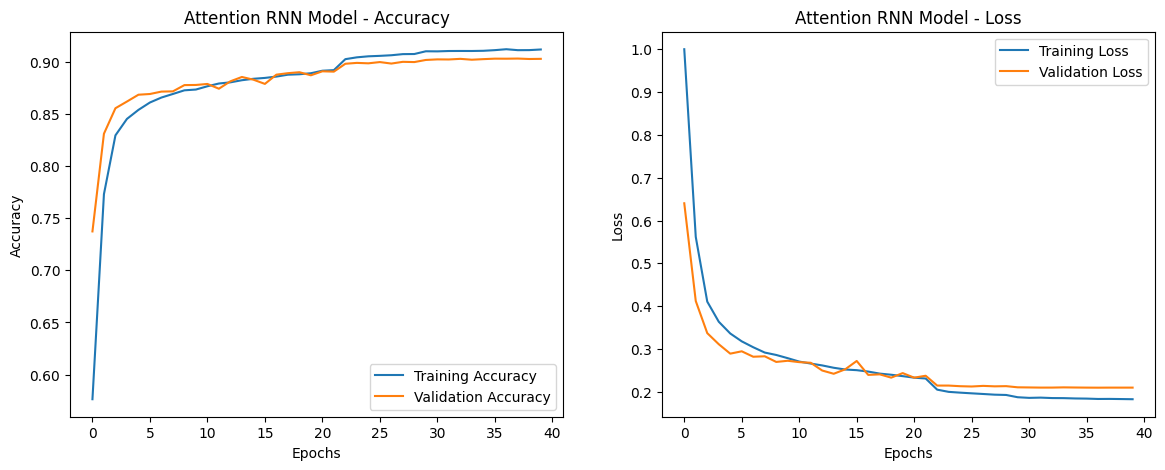

677/677 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

Classification Report for Attention RNN Model
              precision    recall  f1-score   support

       angry       0.94      0.99      0.96      4331
    surprise       0.94      0.98      0.96      4371
         sad       0.81      0.81      0.81      4375
       happy       0.86      0.75      0.80      4320
        fear       0.95      0.98      0.97      4264

    accuracy                           0.90     21661
   macro avg       0.90      0.90      0.90     21661
weighted avg       0.90      0.90      0.90     21661



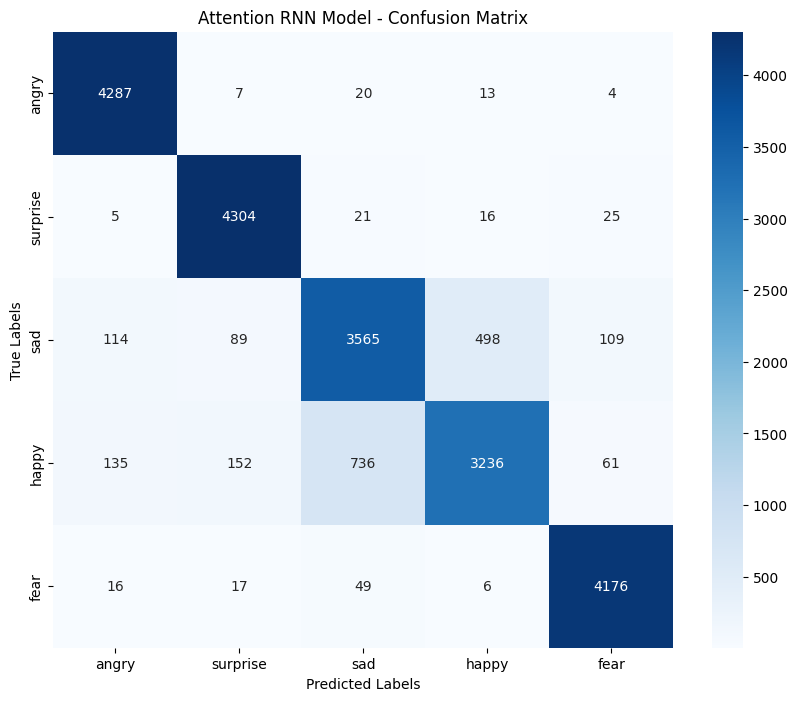

677/677 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


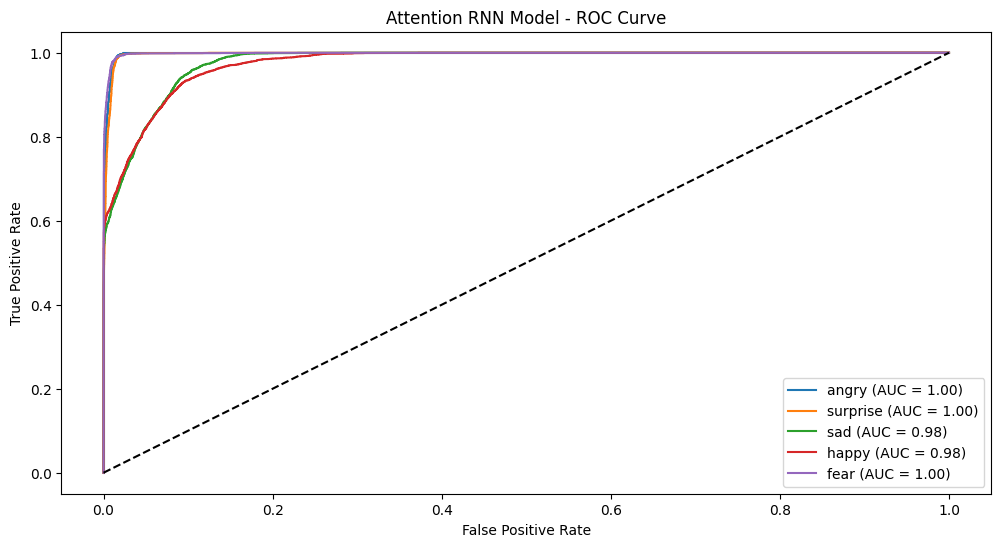

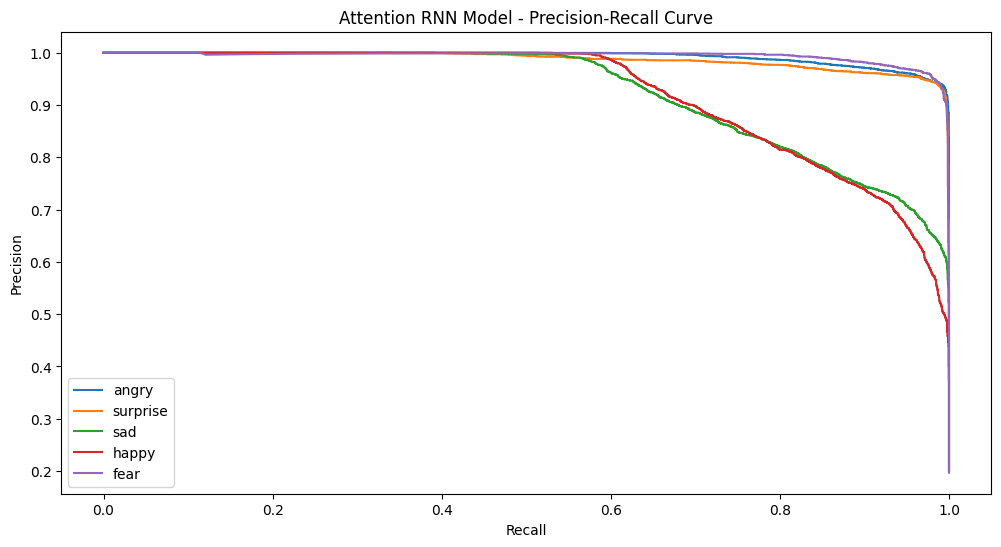


SAVING MODEL FOR STREAMLIT
✅ Music recommendation model saved as 'music_recommendation_model.h5'
✅ Preprocessing objects saved
✅ Feature names saved
🎉 Model is ready for Streamlit deployment!


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Attention
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')

# ---------------------------- Configurations ---------------------------- #
BATCH_SIZE = 32
EPOCHS = 40

# ---------------------------- Selected Classes ---------------------------- #
SELECTED_MOODS = ['angry', 'surprise', 'sad', 'happy', 'fear']
SELECTED_CLASSES = ['angry', 'surprise', 'sad', 'happy', 'fear']

# ---------------------------- Music Data Preprocessing ---------------------------- #
def preprocess_music_data(music_data, selected_features, selected_moods):
    music_data = music_data[music_data['mood'].isin(selected_moods)]

    X_music = music_data[selected_features]
    y_music = music_data['mood']

    scaler = StandardScaler()
    X_music_scaled = scaler.fit_transform(X_music)

    encoder = OneHotEncoder(sparse_output=False)
    y_music_encoded = encoder.fit_transform(y_music.values.reshape(-1, 1))

    # Apply SMOTE to balance the dataset
    smote = SMOTE(random_state=42)
    X_music_balanced, y_music_balanced = smote.fit_resample(X_music_scaled, y_music_encoded)

    music_train_features, music_val_features, music_train_labels, music_val_labels = train_test_split(
        X_music_balanced, y_music_balanced, test_size=0.2, random_state=42
    )

    # Reshape for RNN compatibility
    music_train_features = music_train_features.reshape(-1, len(selected_features), 1)
    music_val_features = music_val_features.reshape(-1, len(selected_features), 1)

    return music_train_features, music_val_features, music_train_labels, music_val_labels, scaler, encoder

# ---------------------------- Attention-Based RNN for Music ---------------------------- #
def build_attention_rnn(input_shape, num_classes):
    """Build an Attention-Based RNN model."""
    inputs = Input(shape=input_shape)
    x = LSTM(64, return_sequences=True)(inputs)
    x = Attention()([x, x])
    x = LSTM(32)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(learning_rate=0.001), loss="categorical_crossentropy", metrics=["accuracy"])
    return model

# ---------------------------- Training and Evaluation ---------------------------- #
def train_and_evaluate_model(model, train_features, train_labels, val_features, val_labels, model_name):
    """Train and evaluate a model."""
    callbacks = [
        EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3),
        ModelCheckpoint(f'best_{model_name}.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
    ]

    history = model.fit(
        train_features, train_labels,
        validation_data=(val_features, val_labels),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks
    )

    score = model.evaluate(val_features, val_labels)
    print(f"Model Test Accuracy: {score[1] * 100:.2f}%")
    return history

# ---------------------------- Plotting Utilities ---------------------------- #
def plot_training_history(history, title):
    plt.figure(figsize=(14, 5))

    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

def plot_confusion_matrix_and_report(model, features, labels, selected_classes, title):
    """Plot confusion matrix and classification report for a model."""
    predictions = model.predict(features)
    predicted_labels = np.argmax(predictions, axis=1)
    true_labels = np.argmax(labels, axis=1)

    # Classification Report
    print(f"\nClassification Report for {title}")
    print(classification_report(true_labels, predicted_labels, target_names=selected_classes))

    # Confusion Matrix
    cm = confusion_matrix(true_labels, predicted_labels)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=selected_classes, yticklabels=selected_classes)
    plt.title(f"{title} - Confusion Matrix")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.show()

def plot_roc_pr_curves(y_true, y_probs, selected_classes, model_name):
    """Plot ROC and Precision-Recall curves."""
    num_classes = y_true.shape[1]

    # ROC Curve
    plt.figure(figsize=(12, 6))
    for i, class_name in enumerate(selected_classes):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f"{model_name} - ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="best")
    plt.show()

    # Precision-Recall Curve
    plt.figure(figsize=(12, 6))
    for i, class_name in enumerate(selected_classes):
        precision, recall, _ = precision_recall_curve(y_true[:, i], y_probs[:, i])
        plt.plot(recall, precision, label=f'{class_name}')
    plt.title(f"{model_name} - Precision-Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend(loc="best")
    plt.show()

# ---------------------------- Execution Example ---------------------------- #
selected_features = [
    'danceability', 'energy', 'valence', 'tempo', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'loudness'
]

# Load Music Data
music_data_path = "/content/music_moods_dataset.csv"
music_data = pd.read_csv(music_data_path)

# Data Preparation
music_train_features, music_val_features, music_train_labels, music_val_labels, scaler, encoder = preprocess_music_data(
    music_data, selected_features, SELECTED_MOODS
)

# Attention RNN Model
rnn_model = build_attention_rnn((len(selected_features), 1), len(SELECTED_CLASSES))
rnn_history = train_and_evaluate_model(rnn_model, music_train_features, music_train_labels, music_val_features, music_val_labels, "music_attention_rnn")

# Plot Training History
plot_training_history(rnn_history, "Attention RNN Model")

# Evaluate Model with Confusion Matrix and Classification Report
plot_confusion_matrix_and_report(rnn_model, music_val_features, music_val_labels, SELECTED_CLASSES, "Attention RNN Model")

# ROC and Precision-Recall Curves
rnn_probs = rnn_model.predict(music_val_features)
plot_roc_pr_curves(music_val_labels, rnn_probs, SELECTED_CLASSES, "Attention RNN Model")

# ---------------------------- SAVE MODEL FOR STREAMLIT ---------------------------- #
print("\n" + "="*50)
print("SAVING MODEL FOR STREAMLIT")
print("="*50)

# Save the final trained model
rnn_model.save('music_recommendation_model.h5')
print("✅ Music recommendation model saved as 'music_recommendation_model.h5'")

# Save preprocessing objects
import joblib
joblib.dump(scaler, 'music_scaler.pkl')
joblib.dump(encoder, 'music_encoder.pkl')

# Save feature names
with open('music_features.json', 'w') as f:
    import json
    json.dump(selected_features, f)

print("✅ Preprocessing objects saved")
print("✅ Feature names saved")
print("🎉 Model is ready for Streamlit deployment!")

Found 22619 images belonging to 6 classes.
Found 5654 images belonging to 6 classes.
Found 7067 images belonging to 6 classes.
Data generators created successfully!
Training samples: 22619
Validation samples: 5654
Test samples: 7067
Building DenseNet121 with Attention...
Building Custom Attention Model...

Training DenseNet121...
Epoch 1/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.2202 - loss: 2.3767
Epoch 1: val_accuracy improved from -inf to 0.30934, saving model to best_densenet.h5


354/354 ━━━━━━━━━━━━━━━━━━━━ 128s 225ms/step - accuracy: 0.2203 - loss: 2.3763 - val_accuracy: 0.3093 - val_loss: 1.7116 - learning_rate: 1.0000e-04
Epoch 2/60
353/354 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.2914 - loss: 2.0276
Epoch 2: val_accuracy improved from 0.30934 to 0.35143, saving model to best_densenet.h5


354/354 ━━━━━━━━━━━━━━━━━━━━ 27s 75ms/step - accuracy: 0.2915 - loss: 2.0274 - val_accuracy: 0.3514 - val_loss: 1.6482 - learning_rate: 1.0000e-04
Epoch 3/60
353/354 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.3068 - loss: 1.8938
Epoch 3: val_accuracy improved from 0.35143 to 0.36470, saving model to best_densenet.h5


354/354 ━━━━━━━━━━━━━━━━━━━━ 26s 74ms/step - accuracy: 0.3068 - loss: 1.8937 - val_accuracy: 0.3647 - val_loss: 1.5971 - learning_rate: 1.0000e-04
Epoch 4/60
353/354 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.3270 - loss: 1.8241
Epoch 4: val_accuracy improved from 0.36470 to 0.38256, saving model to best_densenet.h5


354/354 ━━━━━━━━━━━━━━━━━━━━ 27s 76ms/step - accuracy: 0.3270 - loss: 1.8241 - val_accuracy: 0.3826 - val_loss: 1.5715 - learning_rate: 1.0000e-04
Epoch 5/60
353/354 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.3319 - loss: 1.7887
Epoch 5: val_accuracy improved from 0.38256 to 0.38964, saving model to best_densenet.h5


...

354/354 ━━━━━━━━━━━━━━━━━━━━ 24s 66ms/step - accuracy: 0.6528 - loss: 0.9224 - val_accuracy: 0.6307 - val_loss: 0.9946 - learning_rate: 2.5000e-05
Epoch 47/60
353/354 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6482 - loss: 0.9279
Epoch 47: val_accuracy improved from 0.63070 to 0.63141, saving model to best_custom.h5


354/354 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.6482 - loss: 0.9279 - val_accuracy: 0.6314 - val_loss: 0.9868 - learning_rate: 2.5000e-05
Epoch 48/60
353/354 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.6486 - loss: 0.9256
Epoch 48: val_accuracy improved from 0.63141 to 0.63513, saving model to best_custom.h5


354/354 ━━━━━━━━━━━━━━━━━━━━ 25s 71ms/step - accuracy: 0.6486 - loss: 0.9256 - val_accuracy: 0.6351 - val_loss: 0.9784 - learning_rate: 2.5000e-05
Epoch 49/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.6451 - loss: 0.9408
Epoch 49: val_accuracy did not improve from 0.63513
354/354 ━━━━━━━━━━━━━━━━━━━━ 24s 68ms/step - accuracy: 0.6451 - loss: 0.9408 - val_accuracy: 0.6339 - val_loss: 0.9828 - learning_rate: 2.5000e-05
Epoch 50/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6501 - loss: 0.9171
Epoch 50: val_accuracy did not improve from 0.63513
354/354 ━━━━━━━━━━━━━━━━━━━━ 25s 69ms/step - accuracy: 0.6501 - loss: 0.9171 - val_accuracy: 0.6199 - val_loss: 0.9909 - learning_rate: 2.5000e-05
Epoch 51/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6518 - loss: 0.9132
Epoch 51: val_accuracy did not improve from 0.63513
354/354 ━━━━━━━━━━━━━━━━━━━━ 24s 66ms/step - accuracy: 0.6518 - loss: 0.9132 - val_accuracy: 0.6286 - val_loss: 0.9857 - learning_rate: 2.5

354/354 ━━━━━━━━━━━━━━━━━━━━ 24s 69ms/step - accuracy: 0.6575 - loss: 0.8972 - val_accuracy: 0.6374 - val_loss: 0.9764 - learning_rate: 2.5000e-05
Epoch 56/60
353/354 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6582 - loss: 0.9051
Epoch 56: val_accuracy did not improve from 0.63742
354/354 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.6582 - loss: 0.9051 - val_accuracy: 0.6371 - val_loss: 0.9690 - learning_rate: 2.5000e-05
Epoch 57/60
353/354 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.6558 - loss: 0.9079
Epoch 57: val_accuracy did not improve from 0.63742
354/354 ━━━━━━━━━━━━━━━━━━━━ 24s 68ms/step - accuracy: 0.6558 - loss: 0.9079 - val_accuracy: 0.6358 - val_loss: 0.9709 - learning_rate: 2.5000e-05
Epoch 58/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.6544 - loss: 0.9116
Epoch 58: val_accuracy did not improve from 0.63742
354/354 ━━━━━━━━━━━━━━━━━━━━ 24s 68ms/step - accuracy: 0.6545 - loss: 0.9115 - val_accuracy: 0.6349 - val_loss: 0.9777 - learning_rate: 2.5

354/354 ━━━━━━━━━━━━━━━━━━━━ 24s 69ms/step - accuracy: 0.6655 - loss: 0.8866 - val_accuracy: 0.6403 - val_loss: 0.9677 - learning_rate: 2.5000e-05
Restoring model weights from the end of the best epoch: 60.

Plotting Training History...


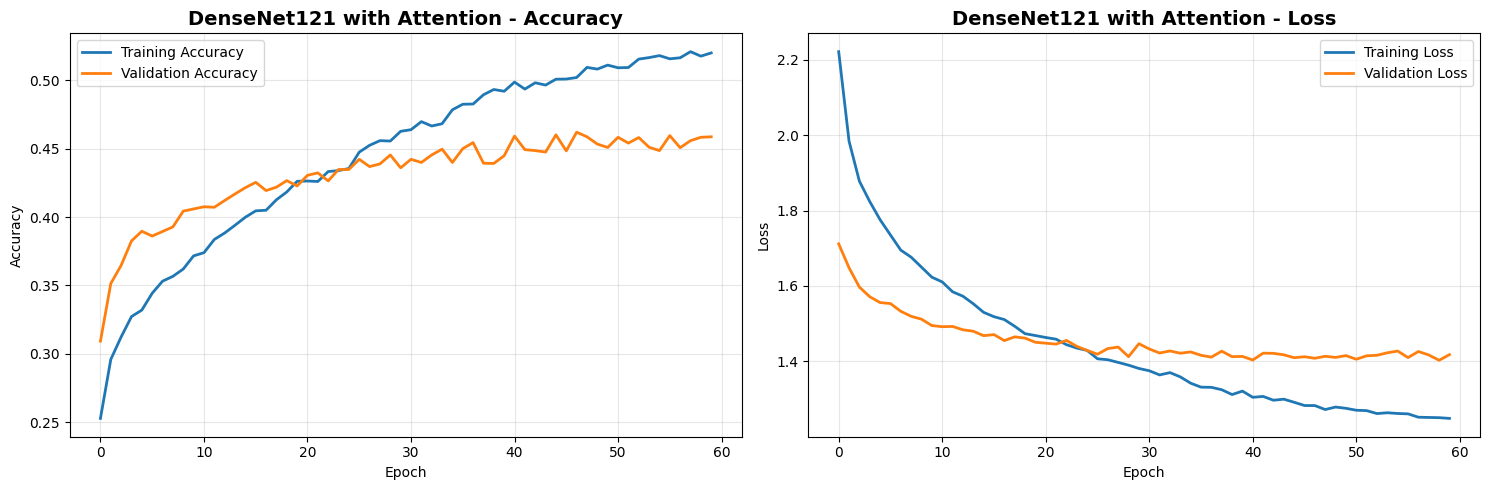


DenseNet121 with Attention Final Metrics:
Training Accuracy: 0.5199
Validation Accuracy: 0.4586
Training Loss: 1.2493
Validation Loss: 1.4181


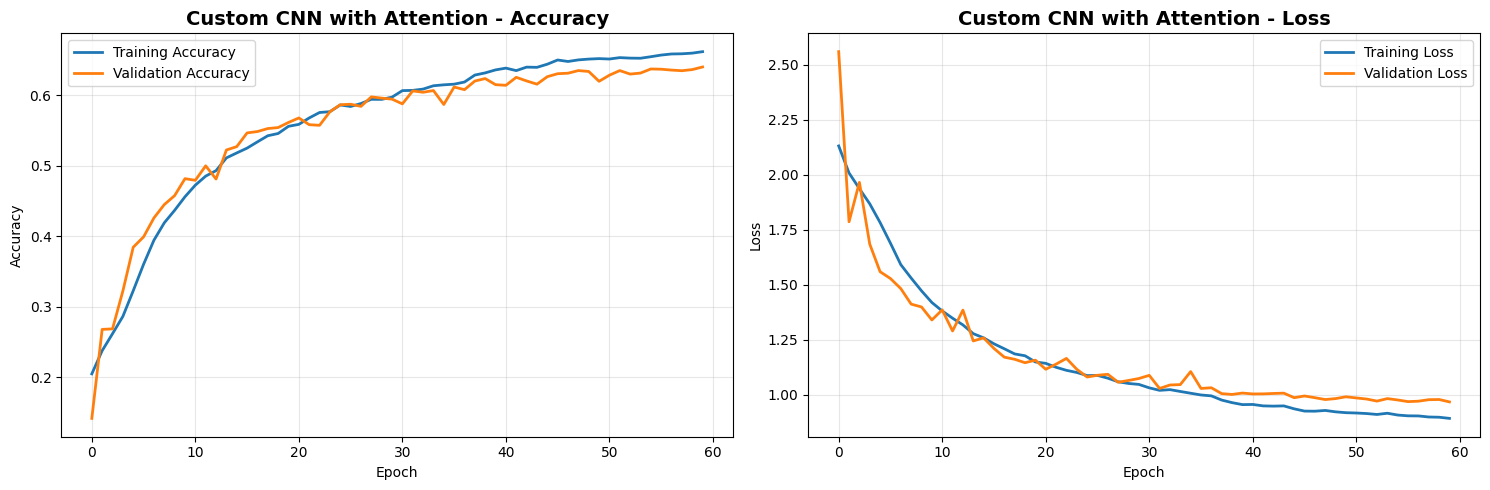


Custom CNN with Attention Final Metrics:
Training Accuracy: 0.6620
Validation Accuracy: 0.6403
Training Loss: 0.8927
Validation Loss: 0.9677


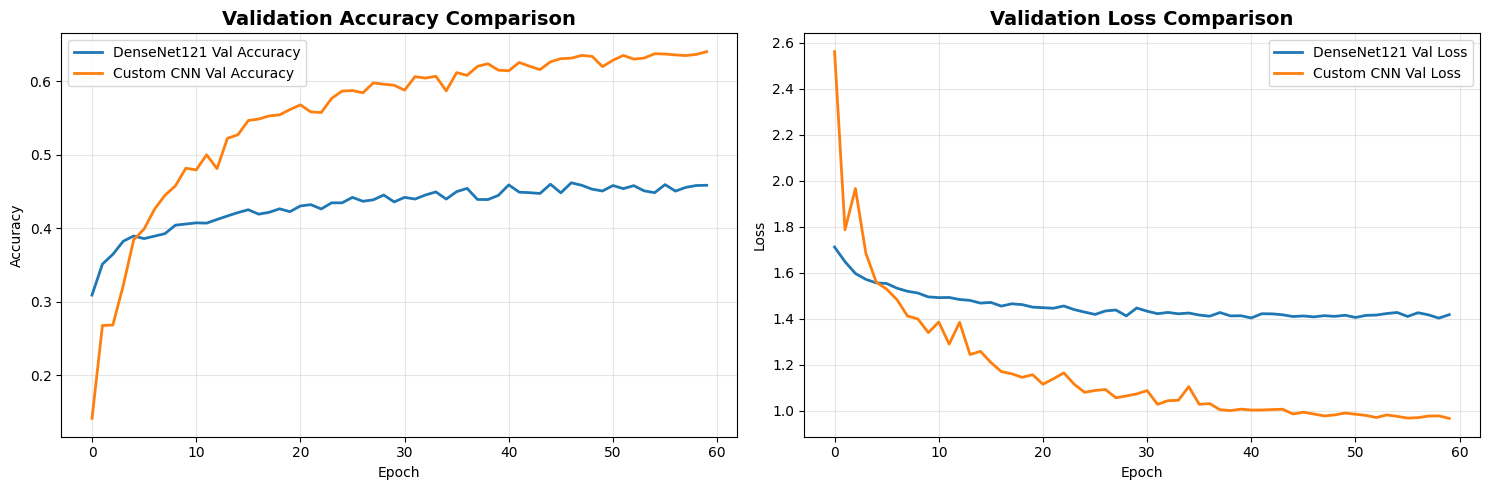


Evaluating Individual Models...
111/111 ━━━━━━━━━━━━━━━━━━━━ 28s 143ms/step
Classification Report for DenseNet121
              precision    recall  f1-score   support

       angry       0.42      0.30      0.35       958
        fear       0.40      0.21      0.28      1024
       happy       0.57      0.75      0.65      1774
     neutral       0.42      0.51      0.46      1233
         sad       0.45      0.34      0.39      1247
    surprise       0.54      0.69      0.61       831

    accuracy                           0.49      7067
   macro avg       0.47      0.47      0.46      7067
weighted avg       0.47      0.49      0.47      7067



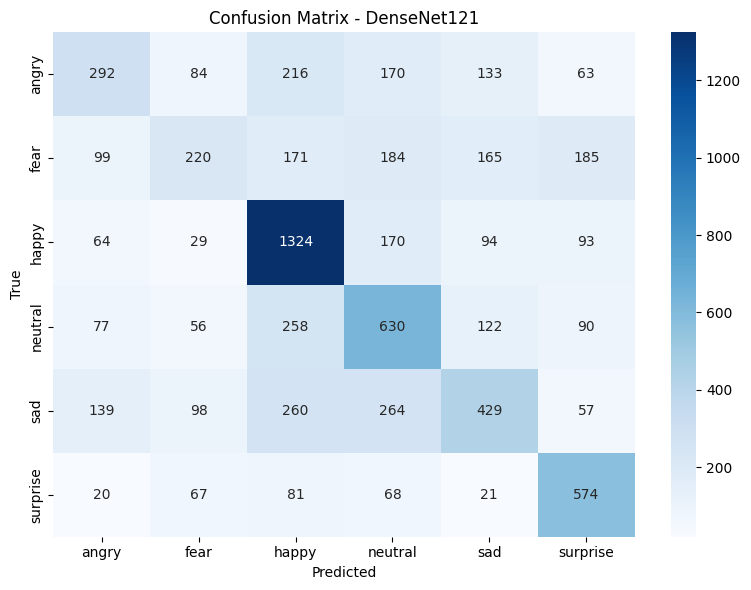

111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step
Classification Report for Custom CNN
              precision    recall  f1-score   support

       angry       0.59      0.60      0.60       958
        fear       0.56      0.30      0.39      1024
       happy       0.83      0.88      0.85      1774
     neutral       0.53      0.71      0.61      1233
         sad       0.55      0.45      0.49      1247
    surprise       0.70      0.84      0.76       831

    accuracy                           0.65      7067
   macro avg       0.63      0.63      0.62      7067
weighted avg       0.64      0.65      0.63      7067



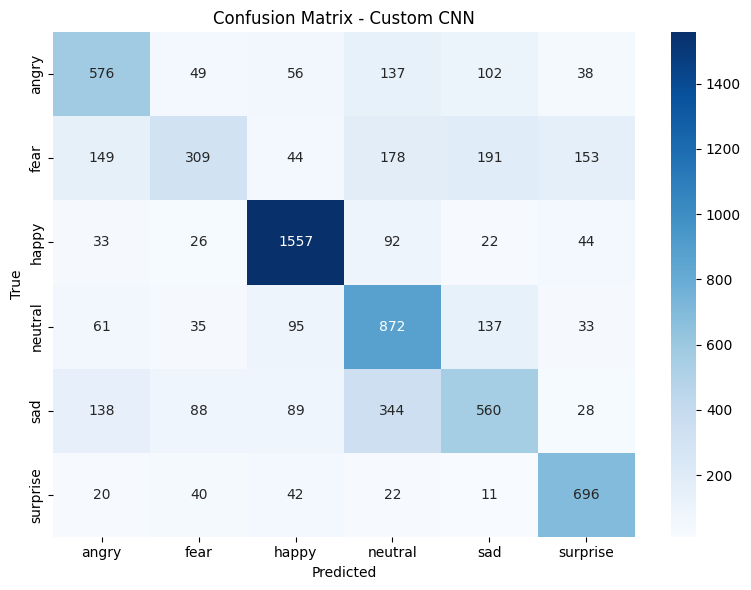


Building Ensemble Model...
111/111 ━━━━━━━━━━━━━━━━━━━━ 29s 145ms/step
Classification Report for Ensemble Model
              precision    recall  f1-score   support

       angry       0.59      0.56      0.57       958
        fear       0.60      0.29      0.39      1024
       happy       0.77      0.89      0.82      1774
     neutral       0.53      0.69      0.60      1233
         sad       0.57      0.44      0.50      1247
    surprise       0.67      0.84      0.74       831

    accuracy                           0.64      7067
   macro avg       0.62      0.62      0.61      7067
weighted avg       0.63      0.64      0.62      7067



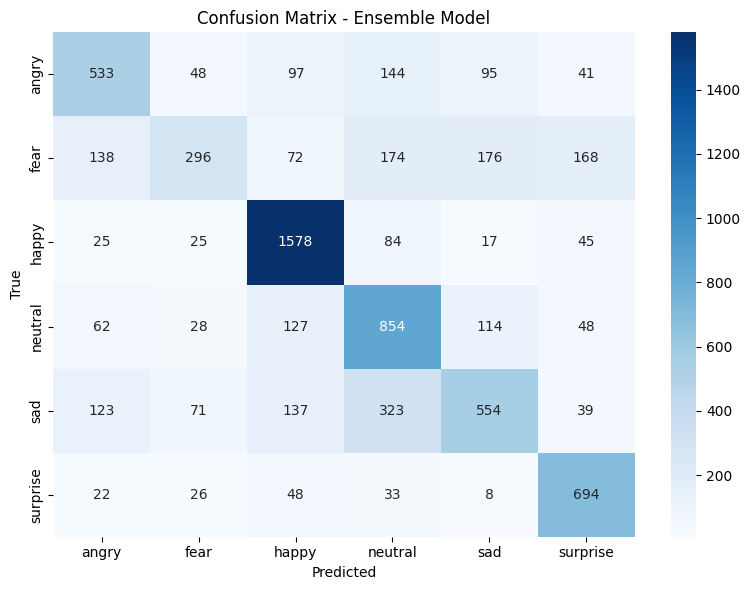


FINAL RESULTS
DenseNet121 Accuracy: 0.4909
Custom CNN Accuracy: 0.6467
Ensemble Accuracy: 0.6380

Saving ensemble model for Streamlit...
✅ Ensemble model saved as 'emotion_model.h5'
✅ Class labels saved as 'class_labels.json'

🎯 Training completed! Use 'emotion_model.h5' in your Streamlit app.


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.layers import Multiply, Activation, Reshape, Lambda, Input, Average
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')

# ---------------------------- Configurations ---------------------------- #
IMAGE_SIZE = 48
BATCH_SIZE = 64
EPOCHS = 60  # Reduced epochs for faster training

TRAIN_PATH = "/content/fer2013/train"
TEST_PATH = "/content/fer2013/test"
SELECTED_CLASSES = ['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise']

# ---------------------------- Attention Mechanisms ---------------------------- #
def channel_attention(input_tensor, reduction_ratio=8):
    """Channel Attention Module (CAM)"""
    channels = input_tensor.shape[-1]
    gap = GlobalAveragePooling2D()(input_tensor)
    gap = Dense(channels // reduction_ratio, activation='relu')(gap)
    gap = Dense(channels, activation='sigmoid')(gap)

    gmp = tf.keras.layers.GlobalMaxPooling2D()(input_tensor)
    gmp = Dense(channels // reduction_ratio, activation='relu')(gmp)
    gmp = Dense(channels, activation='sigmoid')(gmp)

    attention = tf.keras.layers.Add()([gap, gmp])
    attention = Activation('sigmoid')(attention)
    attention = Reshape((1, 1, channels))(attention)
    return Multiply()([input_tensor, attention])

def spatial_attention(input_tensor):
    """Spatial Attention Module (SAM)"""
    avg_pool = Lambda(lambda x: tf.reduce_mean(x, axis=3, keepdims=True))(input_tensor)
    max_pool = Lambda(lambda x: tf.reduce_max(x, axis=3, keepdims=True))(input_tensor)
    concat = tf.keras.layers.Concatenate(axis=3)([avg_pool, max_pool])
    attention = Conv2D(1, (7, 7), padding='same', activation='sigmoid')(concat)
    return Multiply()([input_tensor, attention])

def cbam_attention(input_tensor, reduction_ratio=8):
    """Convolutional Block Attention Module (CBAM)"""
    x = channel_attention(input_tensor, reduction_ratio)
    x = spatial_attention(x)
    return x

# ---------------------------- Data Generators ---------------------------- #
def create_grayscale_generators(train_path, test_path, img_size, batch_size, selected_classes):
    """Create grayscale data generators."""
    train_preprocessor = ImageDataGenerator(
        rescale=1./255,
        rotation_range=15,
        zoom_range=0.2,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,
        validation_split=0.2
    )

    test_preprocessor = ImageDataGenerator(rescale=1./255)

    train_generator = train_preprocessor.flow_from_directory(
        train_path,
        target_size=(img_size, img_size),
        color_mode='grayscale',
        batch_size=batch_size,
        class_mode="categorical",
        subset="training",
        classes=selected_classes,
        shuffle=True
    )

    validation_generator = train_preprocessor.flow_from_directory(
        train_path,
        target_size=(img_size, img_size),
        color_mode='grayscale',
        batch_size=batch_size,
        class_mode="categorical",
        subset="validation",
        classes=selected_classes,
        shuffle=False
    )

    test_generator = test_preprocessor.flow_from_directory(
        test_path,
        target_size=(img_size, img_size),
        color_mode='grayscale',
        batch_size=batch_size,
        class_mode="categorical",
        shuffle=False,
        classes=selected_classes
    )

    return train_generator, validation_generator, test_generator

# ---------------------------- Model Building ---------------------------- #
def build_densenet121_with_attention(input_shape, num_classes):
    """Build DenseNet121 model with CBAM attention."""
    base_model = DenseNet121(
        weights='imagenet',
        include_top=False,
        input_shape=(input_shape[0], input_shape[1], 3)
    )

    inputs = Input(shape=input_shape)
    x = Lambda(lambda x: tf.repeat(x, 3, axis=-1))(inputs)
    x = base_model(x, training=False)
    x = cbam_attention(x, reduction_ratio=16)
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)

    # Fine-tuning
    base_model.trainable = True
    for layer in base_model.layers[:-60]:  # Reduced unfrozen layers
        layer.trainable = False

    return model

def build_custom_attention_model(input_shape, num_classes):
    """Build custom CNN model with attention mechanisms."""
    inputs = Input(shape=input_shape)

    # Block 1
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.25)(x)

    # Block 2 with attention
    x = channel_attention(x, reduction_ratio=8)
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.25)(x)

    # Block 3 with attention
    x = spatial_attention(x)
    x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.25)(x)

    # Classifier
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs)

def build_ensemble_model(densenet_model, custom_model, input_shape, num_classes):
    """Build ensemble model that averages predictions from both models."""
    input_layer = Input(shape=input_shape)

    # Get predictions from both models
    densenet_pred = densenet_model(input_layer)
    custom_pred = custom_model(input_layer)

    # Average the predictions
    averaged = Average()([densenet_pred, custom_pred])

    # Create ensemble model
    ensemble_model = Model(inputs=input_layer, outputs=averaged)

    return ensemble_model

# ---------------------------- Visualization Functions ---------------------------- #
def plot_training_history(history, model_name):
    """Plot accuracy and loss curves for training history."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot accuracy
    ax1.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    ax1.set_title(f'{model_name} - Accuracy', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot loss
    ax2.plot(history.history['loss'], label='Training Loss', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    ax2.set_title(f'{model_name} - Loss', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print final metrics
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    final_train_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]

    print(f"\n{model_name} Final Metrics:")
    print(f"Training Accuracy: {final_train_acc:.4f}")
    print(f"Validation Accuracy: {final_val_acc:.4f}")
    print(f"Training Loss: {final_train_loss:.4f}")
    print(f"Validation Loss: {final_val_loss:.4f}")

def plot_comparison(history_densenet, history_custom):
    """Compare training histories of both models."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Accuracy comparison
    ax1.plot(history_densenet.history['val_accuracy'], label='DenseNet121 Val Accuracy', linewidth=2)
    ax1.plot(history_custom.history['val_accuracy'], label='Custom CNN Val Accuracy', linewidth=2)
    ax1.set_title('Validation Accuracy Comparison', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Loss comparison
    ax2.plot(history_densenet.history['val_loss'], label='DenseNet121 Val Loss', linewidth=2)
    ax2.plot(history_custom.history['val_loss'], label='Custom CNN Val Loss', linewidth=2)
    ax2.set_title('Validation Loss Comparison', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ---------------------------- Callbacks ---------------------------- #
def get_callbacks(model_name):
    """Get callbacks for training."""
    checkpoint = ModelCheckpoint(
        f"best_{model_name}.h5",
        monitor="val_accuracy",
        save_best_only=True,
        mode='max',
        verbose=1
    )

    early_stopping = EarlyStopping(
        monitor="val_accuracy",
        patience=15,
        restore_best_weights=True,
        mode='max',
        verbose=1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )

    return [checkpoint, early_stopping, reduce_lr]

# ---------------------------- Evaluation ---------------------------- #
def evaluate_model(model, generator, selected_classes, title):
    """Evaluate model and plot confusion matrix."""
    predictions = model.predict(generator)
    pred_classes = np.argmax(predictions, axis=1)
    true_classes = generator.classes

    print(f"Classification Report for {title}")
    print(classification_report(true_classes, pred_classes, target_names=selected_classes))

    # Confusion Matrix
    cm = confusion_matrix(true_classes, pred_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=selected_classes, yticklabels=selected_classes)
    plt.title(f"Confusion Matrix - {title}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    return np.mean(pred_classes == true_classes)

# ---------------------------- Main Pipeline ---------------------------- #
if __name__ == "__main__":
    # Create data generators
    train_gen, val_gen, test_gen = create_grayscale_generators(
        TRAIN_PATH, TEST_PATH, IMAGE_SIZE, BATCH_SIZE, SELECTED_CLASSES
    )

    print("Data generators created successfully!")
    print(f"Training samples: {train_gen.samples}")
    print(f"Validation samples: {val_gen.samples}")
    print(f"Test samples: {test_gen.samples}")

    # Build models
    print("Building DenseNet121 with Attention...")
    densenet_model = build_densenet121_with_attention((IMAGE_SIZE, IMAGE_SIZE, 1), len(SELECTED_CLASSES))
    densenet_model.compile(optimizer=Adam(0.0001), loss="categorical_crossentropy", metrics=["accuracy"])

    print("Building Custom Attention Model...")
    custom_model = build_custom_attention_model((IMAGE_SIZE, IMAGE_SIZE, 1), len(SELECTED_CLASSES))
    custom_model.compile(optimizer=Adam(0.0001), loss="categorical_crossentropy", metrics=["accuracy"])

    # Train models
    print("\nTraining DenseNet121...")
    history_densenet = densenet_model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=get_callbacks("densenet"),
        verbose=1
    )

    print("\nTraining Custom Model...")
    history_custom = custom_model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=get_callbacks("custom"),
        verbose=1
    )

    # Plot training history for both models
    print("\nPlotting Training History...")
    plot_training_history(history_densenet, "DenseNet121 with Attention")
    plot_training_history(history_custom, "Custom CNN with Attention")

    # Plot comparison between models
    plot_comparison(history_densenet, history_custom)

    # Evaluate individual models
    print("\nEvaluating Individual Models...")
    densenet_acc = evaluate_model(densenet_model, test_gen, SELECTED_CLASSES, "DenseNet121")
    custom_acc = evaluate_model(custom_model, test_gen, SELECTED_CLASSES, "Custom CNN")

    # Build and save ensemble model
    print("\nBuilding Ensemble Model...")
    ensemble_model = build_ensemble_model(densenet_model, custom_model, (IMAGE_SIZE, IMAGE_SIZE, 1), len(SELECTED_CLASSES))
    ensemble_model.compile(optimizer=Adam(0.0001), loss="categorical_crossentropy", metrics=["accuracy"])

    # Evaluate ensemble
    ensemble_acc = evaluate_model(ensemble_model, test_gen, SELECTED_CLASSES, "Ensemble Model")

    # Print results
    print("\n" + "="*50)
    print("FINAL RESULTS")
    print("="*50)
    print(f"DenseNet121 Accuracy: {densenet_acc:.4f}")
    print(f"Custom CNN Accuracy: {custom_acc:.4f}")
    print(f"Ensemble Accuracy: {ensemble_acc:.4f}")

    # Save the ensemble model for Streamlit
    print("\nSaving ensemble model for Streamlit...")
    ensemble_model.save('emotion_model.h5')
    print("✅ Ensemble model saved as 'emotion_model.h5'")

    # Save class labels for reference
    import json
    with open('class_labels.json', 'w') as f:
        json.dump(SELECTED_CLASSES, f)
    print("✅ Class labels saved as 'class_labels.json'")

    print("\n🎯 Training completed! Use 'emotion_model.h5' in your Streamlit app.")